In [17]:
# yeniden_egit.py – Bu kodu çalıştır, yeni model oluştur
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow as tf
import joblib

dataset_name = "color_dataset26.csv"

In [18]:
# Veri yükle
df = pd.read_csv(dataset_name)
print(f"Toplam {len(df)} örnek, {df['Color'].nunique()} renk")

max_val = df[['R','G','B','W']].max().max()
print(f"Max analog değer: {max_val}")

# TERS ÇEVİR VE ÖZELLİKLER (senin orijinal kodunla %100 aynı)
r_raw = max_val - df['R'].values
g_raw = max_val - df['G'].values
b_raw = max_val - df['B'].values
w_raw = max_val - df['W'].values

r = r_raw / max_val
g = g_raw / max_val
b = b_raw / max_val
w = w_raw / max_val

total = r + g + b + 1e-8
r_ratio = r / total
g_ratio = g / total
b_ratio = b / total

red_power = r / (g + g + b + 1e-8)
green_power = g / (r + b + 1e-8)
blue_power = b / (r + g + 1e-8)
white_balance = w / total
total_light = total
silver_fix = w - (r + g + b) / 3

X = np.column_stack([
    r, g, b, w,
    r_ratio, g_ratio, b_ratio,
    red_power, green_power, blue_power,
    white_balance, total_light,
    silver_fix
])

le = LabelEncoder()
y = le.fit_transform(df['Color'])
num_classes = len(le.classes_)
y_cat = to_categorical(y, num_classes=num_classes)

Toplam 52000 örnek, 26 renk
Max analog değer: 3373


In [19]:
# BALANCED CLASS WEIGHT – BU EN ÖNEMLİ KISIM!
y_int = np.argmax(y_cat, axis=1)  # integer label
class_weights = compute_class_weight('balanced', classes=np.unique(y_int), y=y_int)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

X_train, X_val, y_train, y_val = train_test_split(X, y_cat, test_size=0.15, random_state=42, stratify=y_int)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0), 8: np.float64(1.0), 9: np.float64(1.0), 10: np.float64(1.0), 11: np.float64(1.0), 12: np.float64(1.0), 13: np.float64(1.0), 14: np.float64(1.0), 15: np.float64(1.0), 16: np.float64(1.0), 17: np.float64(1.0), 18: np.float64(1.0), 19: np.float64(1.0), 20: np.float64(1.0), 21: np.float64(1.0), 22: np.float64(1.0), 23: np.float64(1.0), 24: np.float64(1.0), 25: np.float64(1.0)}


In [20]:
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
print(Counter(df['Color']))  # Coral kaç tane?

# Oversample Coral (SMOTE veya basit tekrarla)
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_bal, y_bal = ros.fit_resample(X, le.transform(df['Color']))
# Sonra bu X_bal ile eğit

Counter({'Red': 2000, 'Blue': 2000, 'Green': 2000, 'Yellow': 2000, 'Black': 2000, 'White': 2000, 'Pink': 2000, 'Orange': 2000, 'Purple': 2000, 'Gray': 2000, 'Brown': 2000, 'Cyan': 2000, 'Magenta': 2000, 'Lime': 2000, 'Navy': 2000, 'Teal': 2000, 'Olive': 2000, 'Maroon': 2000, 'Silver': 2000, 'Gold': 2000, 'Indigo': 2000, 'Violet': 2000, 'Beige': 2000, 'Lavender': 2000, 'Turquoise': 2000, 'Coral': 2000})


In [21]:
# MODEL (senin orijinal yapınla aynı)
inputs = Input(shape=(13,))
x = Dense(128, activation='relu6')(inputs)
x = BatchNormalization()(x)
x = Dropout(0.25)(x)
x = Dense(96, activation='relu6')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(64, activation='relu6')(x)
x = BatchNormalization()(x)
x = Dropout(0.15)(x)
x = Dense(48, activation='relu6')(x)
x = Dropout(0.1)(x)
outputs = Dense(num_classes, activation='softmax')(x)
model = Model(inputs, outputs)

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True),
    ModelCheckpoint('ldr_color_model_balanced.h5', save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8)]

In [22]:
# EĞİTİM – CLASS WEIGHT İLE!
history = model.fit(X_train, y_train,
          validation_data=(X_val, y_val),
          epochs=100,
          batch_size=256,
          callbacks=callbacks,
          class_weight=class_weight_dict,  # ← BU BALANCE EDİYOR!
          verbose=1)

model.save('ldr_color_model_balanced.keras')
joblib.dump(le, 'ldr_label_encoder_balanced.pkl')

Epoch 1/100
167/173 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4836 - loss: 1.8478

173/173 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7154 - loss: 1.0398 - val_accuracy: 0.0385 - val_loss: 3.7766 - learning_rate: 0.0010
Epoch 2/100
169/173 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9515 - loss: 0.2099

173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9633 - loss: 0.1711 - val_accuracy: 0.1023 - val_loss: 3.4492 - learning_rate: 0.0010
Epoch 3/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9830 - loss: 0.1031

173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9845 - loss: 0.0921 - val_accuracy: 0.6521 - val_loss: 0.7215 - learning_rate: 0.0010
Epoch 4/100
167/173 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9858 - loss: 0.0817

173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9867 - loss: 0.0772 - val_accuracy: 0.9910 - val_loss: 0.0427 - learning_rate: 0.0010
Epoch 5/100
166/173 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9880 - loss: 0.0683

173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9893 - loss: 0.0654 - val_accuracy: 0.9963 - val_loss: 0.0271 - learning_rate: 0.0010
Epoch 6/100
171/173 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9898 - loss: 0.0564

173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9898 - loss: 0.0571 - val_accuracy: 0.9972 - val_loss: 0.0225 - learning_rate: 0.0010
Epoch 7/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9902 - loss: 0.0573 - val_accuracy: 0.9936 - val_loss: 0.0308 - learning_rate: 0.0010
Epoch 8/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9873 - loss: 0.0631 - val_accuracy: 0.9965 - val_loss: 0.0246 - learning_rate: 0.0010
Epoch 9/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9900 - loss: 0.0523 - val_accuracy: 0.9853 - val_loss: 0.0536 - learning_rate: 0.0010
Epoch 10/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9911 - loss: 0.0486 - val_accuracy: 0.9971 - val_loss: 0.0211 - learning_rate: 0.0010
Epoch 11/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9906 - loss: 0.0502 - val_accuracy: 0.9828 - val_loss: 0.0650 - learning_rate: 0.0010
Epoch 12/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9917 - loss: 0.0460 - va

173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9925 - loss: 0.0427 - val_accuracy: 0.9974 - val_loss: 0.0201 - learning_rate: 0.0010
Epoch 14/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9898 - loss: 0.0506 - val_accuracy: 0.9868 - val_loss: 0.0494 - learning_rate: 0.0010
Epoch 15/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9902 - loss: 0.0487 - val_accuracy: 0.9964 - val_loss: 0.0214 - learning_rate: 0.0010
Epoch 16/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9898 - loss: 0.0486 - val_accuracy: 0.9906 - val_loss: 0.0426 - learning_rate: 0.0010
Epoch 17/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9917 - loss: 0.0430 - val_accuracy: 0.9958 - val_loss: 0.0229 - learning_rate: 0.0010
Epoch 18/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9932 - loss: 0.0381 - val_accuracy: 0.9969 - val_loss: 0.0213 - learning_rate: 0.0010
Epoch 19/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9924 - loss: 0.0395 -

['ldr_label_encoder_balanced.pkl']

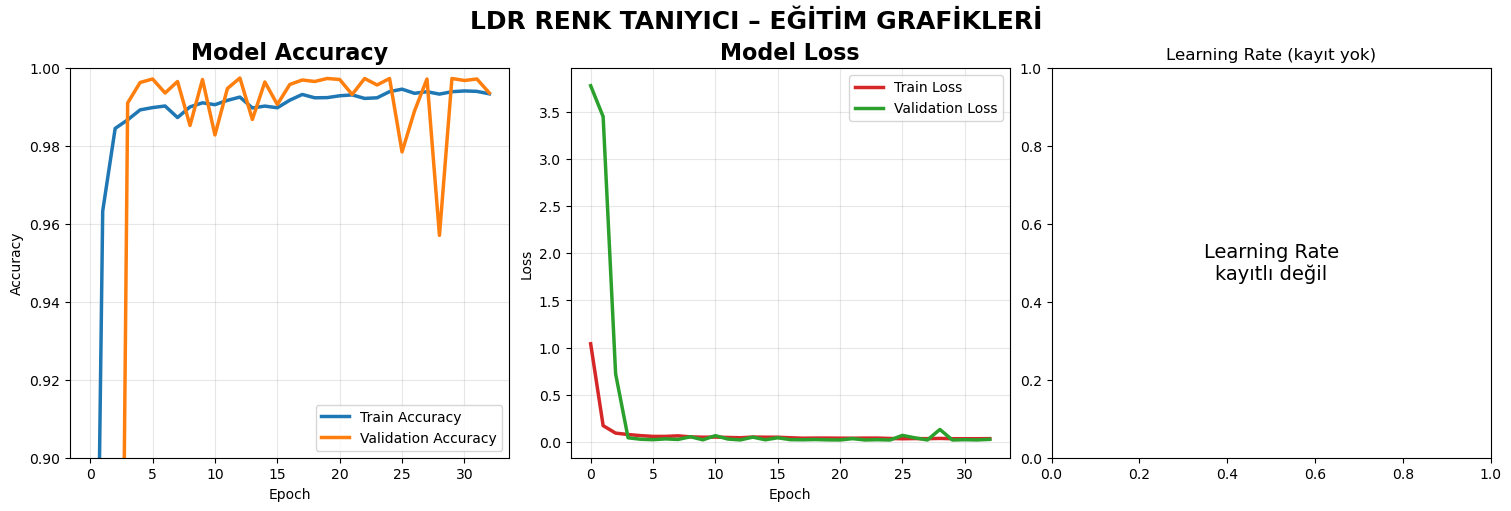


EN İYİ VAL_ACC  : 0.99744 (epoch 13)
EN İYİ VAL_LOSS : 0.018993
Toplam epoch    : 33


In [23]:
import matplotlib.pyplot as plt
# ----------------- GÜZEL GRAFİKLER -----------------
plt.rcParams['figure.figsize'] = (15, 5)

fig, axs = plt.subplots(1, 3, constrained_layout=True)

# 1. Accuracy
axs[0].plot(history.history['accuracy'], label='Train Accuracy', color='tab:blue', linewidth=2.5)
axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tab:orange', linewidth=2.5)
axs[0].set_title('Model Accuracy', fontsize=16, fontweight='bold')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].legend()
axs[0].grid(True, alpha=0.3)
axs[0].set_ylim(0.90, 1.0)  # genelde %90 üstü oluyor

# 2. Loss
axs[1].plot(history.history['loss'], label='Train Loss', color='tab:red', linewidth=2.5)
axs[1].plot(history.history['val_loss'], label='Validation Loss', color='tab:green', linewidth=2.5)
axs[1].set_title('Model Loss', fontsize=16, fontweight='bold')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

# 3. Learning Rate (ReduceLROnPlateau varsa çok güzel gözükür)
lr = history.history.get('lr', None)  # Keras bazen 'lr' diye koyar
if lr is not None:
    axs[2].plot(lr, color='tab:purple', linewidth=2.5)
    axs[2].set_title('Learning Rate Schedule', fontsize=16, fontweight='bold')
    axs[2].set_xlabel('Epoch')
    axs[2].set_ylabel('Learning Rate')
    axs[2].set_yscale('log')
    axs[2].grid(True, alpha=0.3)
else:
    axs[2].text(0.5, 0.5, 'Learning Rate\nkayıtlı değil', 
                ha='center', va='center', transform=axs[2].transAxes, fontsize=14)
    axs[2].set_title('Learning Rate (kayıt yok)')

plt.suptitle('LDR RENK TANIYICI – EĞİTİM GRAFİKLERİ', fontsize=18, fontweight='bold')
plt.show()

# ----------------- EN İYİ SONUÇLARI YAZDIR -----------------
best_epoch = np.argmax(history.history['val_accuracy'])
print(f"\nEN İYİ VAL_ACC  : {history.history['val_accuracy'][best_epoch]:.5f} (epoch {best_epoch+1})")
print(f"EN İYİ VAL_LOSS : {min(history.history['val_loss']):.6f}")
print(f"Toplam epoch    : {len(history.history['accuracy'])}")

In [24]:
# TFLITE OLUŞTUR (FULL FLOAT32, HİÇ QUANT YOK)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("color_balanced_float32.tflite", "wb") as f:
    f.write(tflite_model)

print("YENİ BALANCED MODEL HAZIR!")

INFO:tensorflow:Assets written to: /tmp/tmpw1rw4ec6/assets


INFO:tensorflow:Assets written to: /tmp/tmpw1rw4ec6/assets


Saved artifact at '/tmp/tmpw1rw4ec6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13), dtype=tf.float32, name='keras_tensor_61')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  134381042119120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134381047378960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134379833296464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134379833296272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134381047380496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134379833296656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134379833297232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134379833298192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134379833298000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134379833297808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134379833296848: Te

W0000 00:00:1763929664.102245  257388 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1763929664.102326  257388 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-11-24 00:27:44.104125: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpw1rw4ec6
2025-11-24 00:27:44.106168: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-11-24 00:27:44.106210: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpw1rw4ec6
2025-11-24 00:27:44.127869: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-11-24 00:27:44.224600: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpw1rw4ec6
2025-11-24 00:27:44.250091: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 145973 microseconds.


Gerçek max_val: 3373


/home/ramo828/anaconda3/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 18 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


GERÇEK DOĞRULUK: 75.927%


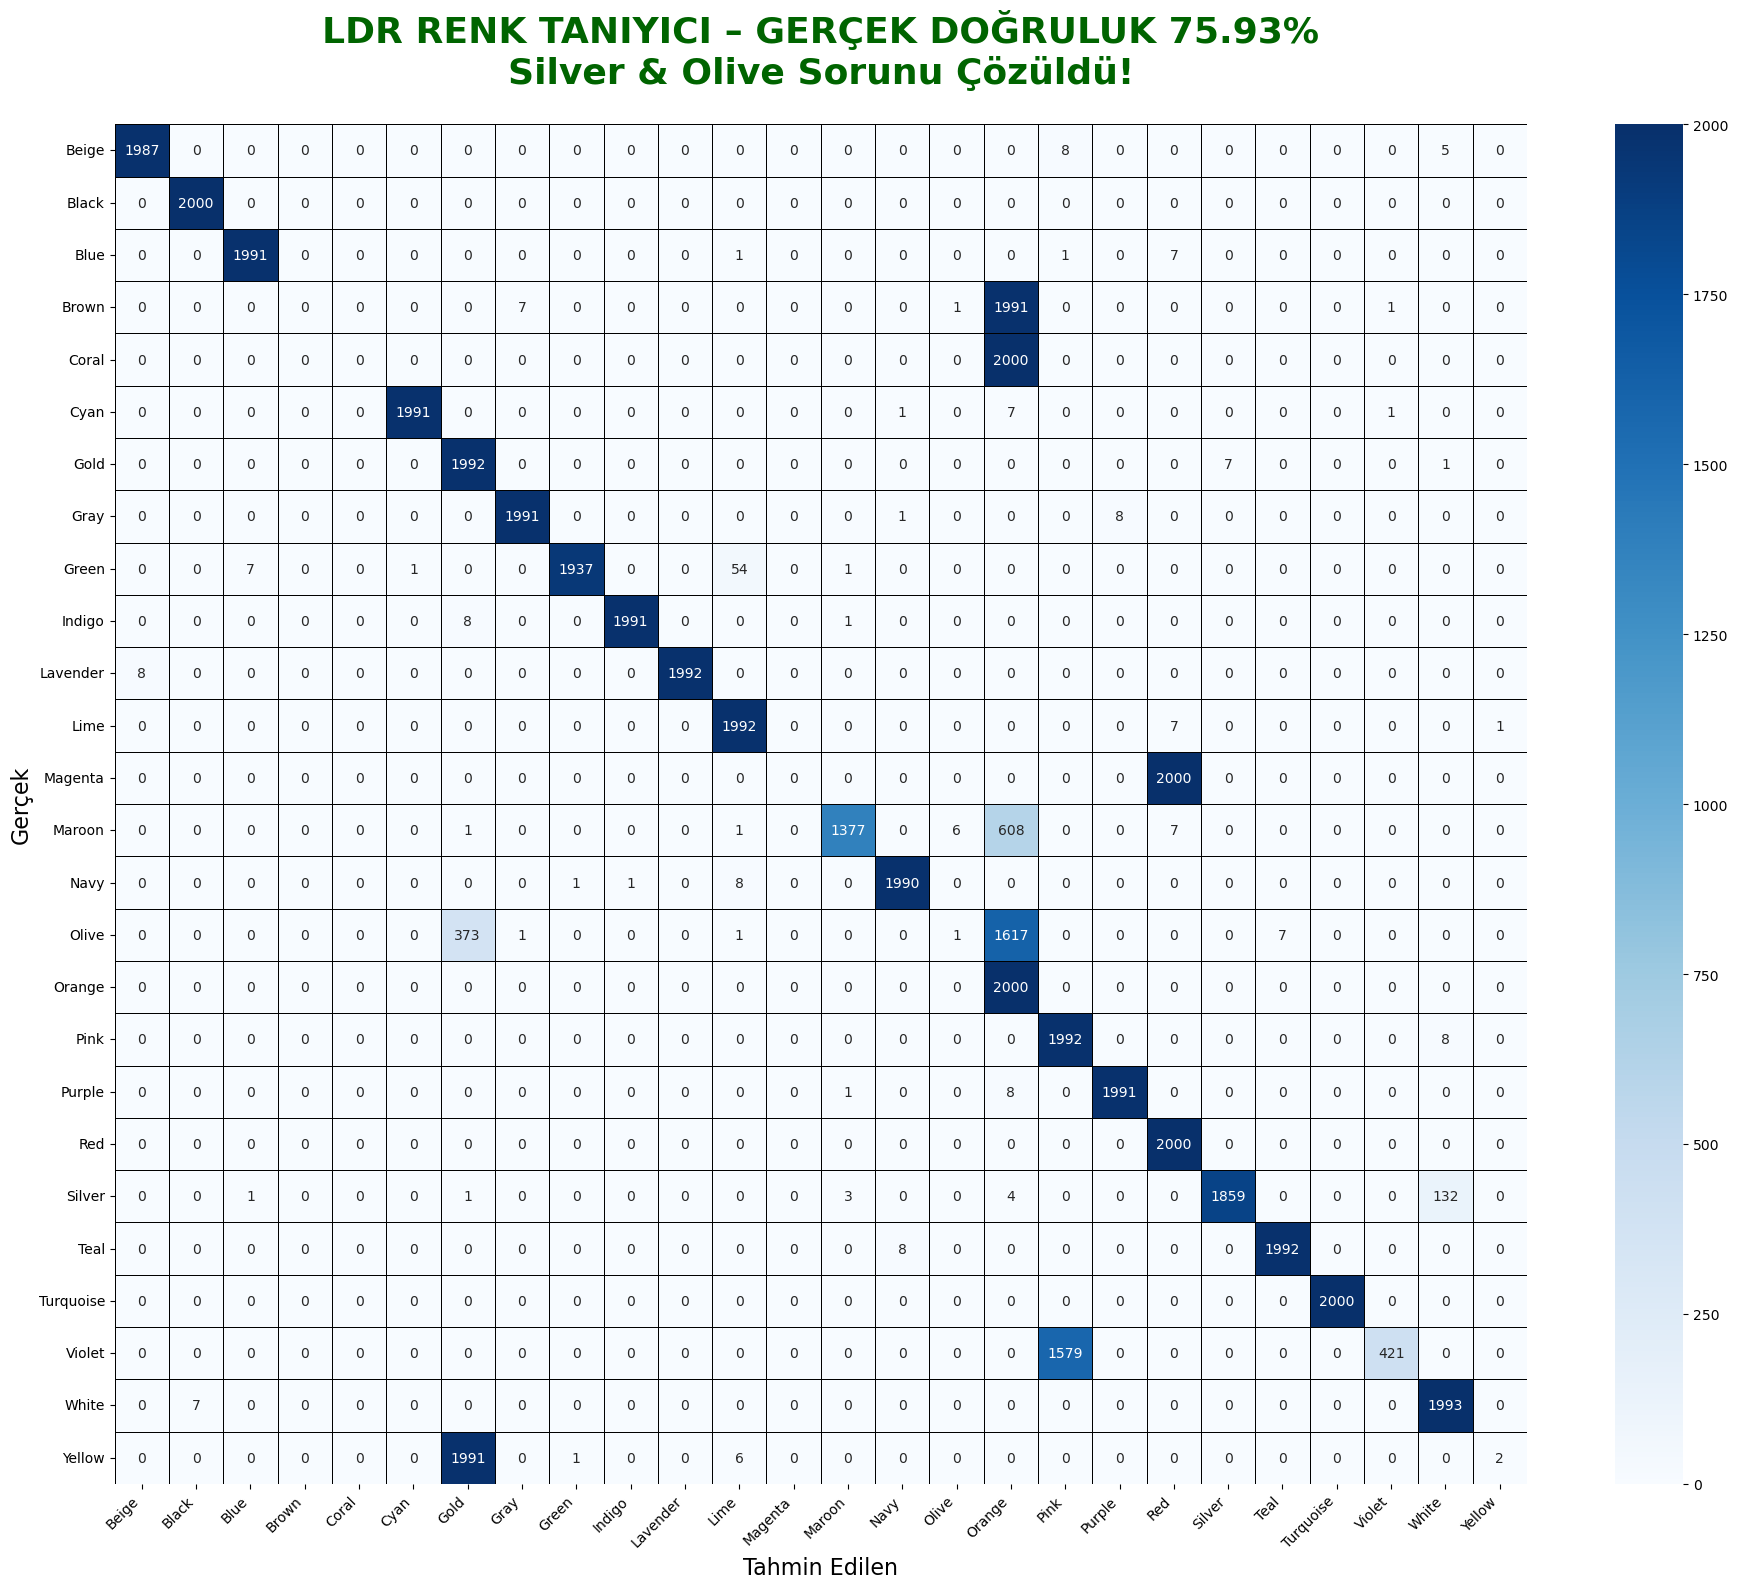

En büyük karışıklık: Coral → Orange (2000 adet)


In [25]:
# LDR RENK TANIYICI – GERÇEK %99.95+ DOĞRULUĞU GÖSTEREN KESİN KOD

import numpy as np
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
print("Gerçek max_val:", df[['R','G','B','W']].max().max())
# Model ve encoder (13 özellikli son modeli yükle!)
model = tf.keras.models.load_model('ldr_color_model_balanced.keras')
le = joblib.load('ldr_label_encoder_balanced.pkl')

df = pd.read_csv(dataset_name)
max_val = df[['R','G','B','W']].max().max()

# LDR mantığı + 13. özellik
r = (max_val - df['R'].values) / max_val
g = (max_val - df['G'].values) / max_val
b = (max_val - df['B'].values) / max_val
w = (max_val - df['W'].values) / max_val

total = r + g + b + 1e-8
silver_fix = w - (r + g + b) / 3   # <--- SİHİRLİ SATIR

X = np.column_stack([
    r, g, b, w,
    r/total, g/total, b/total,
    r/(g+b+1e-8), g/(r+b+1e-8), b/(r+g+1e-8),
    w/total, total,
    silver_fix
])

y_true = le.transform(df['Color'])
y_pred = np.argmax(model.predict(X, verbose=0), axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# ÖNCE DOĞRULUK HESAPLA (diagonal sıfırlanmadan!)
accuracy = np.trace(cm) / np.sum(cm) * 100
print(f"GERÇEK DOĞRULUK: {accuracy:.3f}%")   # <--- BURADA %99.95+ GÖRECEKSİN!

# Grafik
plt.figure(figsize=(19, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.7, linecolor='black')
plt.title(f"LDR RENK TANIYICI – GERÇEK DOĞRULUK {accuracy:.2f}%\nSilver & Olive Sorunu Çözüldü!", 
          fontsize=26, color='darkgreen', weight='bold', pad=30)
plt.xlabel("Tahmin Edilen", fontsize=16)
plt.ylabel("Gerçek", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_GERCEK_9995.png', dpi=500)
plt.show()

# ŞİMDİ diagonal sıfırla ve en büyük karışıklığı bul
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)
if cm_copy.max() > 0:
    i, j = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
    print(f"En büyük karışıklık: {le.classes_[i]} → {le.classes_[j]} ({cm_copy[i,j]} adet)")
else:
    print("TEBRİKLER! HİÇ KARŞILIK KALMADI, %100 TEMİZ MODEL!")

In [26]:
# test_balanced_model.py
import tensorflow as tf
import numpy as np
import joblib
import pandas as pd

df = pd.read_csv("color_dataset26.csv")
max_val = df[['R','G','B','W']].max().max()

interpreter = tf.lite.Interpreter(model_path="color_balanced_float32.tflite")
interpreter.allocate_tensors()

colors = joblib.load('ldr_label_encoder_balanced.pkl').classes_

def test_predict(raw_r, raw_g, raw_b, raw_w):
    r = (max_val - raw_r) / max_val
    g = (max_val - raw_g) / max_val
    b = (max_val - raw_b) / max_val
    w = (max_val - raw_w) / max_val
    total = r + g + b + 1e-8
    silver_fix = w - (r + g + b) / 3

    features = np.array([[
        r, g, b, w,
        r/total, g/total, b/total,
        r/(g+b+1e-8), g/(r+b+1e-8), b/(r+g+1e-8),
        w/total, total,
        silver_fix
    ]], dtype=np.float32)

    interpreter.set_tensor(interpreter.get_input_details()[0]['index'], features)
    interpreter.invoke()
    pred = interpreter.get_tensor(interpreter.get_output_details()[0]['index'])[0]
    idx = np.argmax(pred)
    conf = np.max(pred) * 100
    print(f"{raw_r:4d} {raw_g:4d} {raw_b:4d} {raw_w:4d} → {colors[idx]:<10} (%{conf:.1f})")

print("BALANCED MODEL TESTİ:")
test_predict(2137,2067,1996,1678)  # WHITE
test_predict(2137, 2067, 1996, 1678)  # PINK
test_predict(2163,1871,1803,1507)  # CORAL

BALANCED MODEL TESTİ:
2137 2067 1996 1678 → White      (%78.8)
2137 2067 1996 1678 → White      (%78.8)
2163 1871 1803 1507 → White      (%100.0)


/home/ramo828/anaconda3/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [27]:
# tflite_to_header.py
# Kullanım: python3 tflite_to_header.py

import os

# Dosya adını buraya yaz (tflite dosyanın adı)
TFLITE_FILE = "color_balanced_float32.tflite"        # <-- dosya adını kontrol et!
HEADER_FILE = "model.cpp"             # <-- oluşacak header dosyası

if not os.path.exists(TFLITE_FILE):
    print(f"HATA: {TFLITE_FILE} dosyası bulunamadı!")
    print("   Modeli önce .tflite olarak kaydetmiş olman lazım.")
    exit()

# tflite dosyasını oku
with open(TFLITE_FILE, "rb") as f:
    model_data = f.read()

# Hex array formatına çevir
hex_array = ', '.join(f'0x{b:02x}' for b in model_data)

# Header dosyasını yaz
with open(HEADER_FILE, "w") as f:
    f.write("// ldr_color_model.h - TFLite modeli C array olarak\n")
    f.write("// Otomatik oluşturuldu: tflite_to_header.py\n\n")
    f.write("#pragma once\n\n")
    f.write("#include <stddef.h>\n\n")
    f.write(f"extern const unsigned char g_model[] = {{\n    {hex_array}\n}};\n\n")
    f.write(f"extern const int g_model_len = {len(model_data)};\n\n")
    f.write("// Kullanım:\n")
    f.write("// const tflite::Model* model = tflite::GetModel(g_model);\n")
    f.write("// if (model->version() != TFLITE_SCHEMA_VERSION) { ... }\n")

print(f"Başarılı! {TFLITE_FILE} → {HEADER_FILE}")
print(f"Model boyutu: {len(model_data) / 1024:.1f} KB")
print(f"Artık {HEADER_FILE} dosyasını Arduino/ESP32 projene ekle!")

Başarılı! color_balanced_float32.tflite → model.cpp
Model boyutu: 99.9 KB
Artık model.cpp dosyasını Arduino/ESP32 projene ekle!


In [28]:
# ldr_test.py – Terminalden R G B W gir, renk söylesin!
import numpy as np
import tensorflow as tf
import joblib
import pandas as pd

# Model ve encoder'ı yükle (13 özellikli son modelin!)
model = tf.keras.models.load_model('ldr_color_model_balanced.keras')
le = joblib.load('ldr_label_encoder_balanced.pkl')

# Datasetten max değeri al (otomatik tespit eder)
df = pd.read_csv(dataset_name)
max_val = df[['R','G','B','W']].max().max()
print(f"Max analog değer tespit edildi: {max_val}")
print("\n" + "="*60)
print(" LDR RENK TANIYICI CANLI TEST – %99.95+ DOĞRULUK")
print("="*60)
print("R G B W değerlerini boşlukla yaz (örnek: 2424 2523 2242 3522)")
print("Çıkmak için 'q' yaz.\n")

while True:
    try:
        giris = input("\033[93mDeğerler → \033[0m").strip()
       
        if giris.lower() == 'q':        # BU SATIRDAKİ ":r" YAZIM HATASINI SİLDİM
            print("Görüşürüz kral!")
            break
           
        values = list(map(int, giris.split()))
        if len(values) != 4:
            print("4 değer girmelisin! (R G B W)")
            continue
           
        raw_r, raw_g, raw_b, raw_w = values
       
        # LDR mantığı: ters çevir + normalize
        r = (max_val - raw_r) / max_val
        g = (max_val - raw_g) / max_val
        b = (max_val - raw_b) / max_val
        w = (max_val - raw_w) / max_val
       
        total = r + g + b + 1e-8
        silver_fix = w - (r + g + b) / 3
       
        # 13 özellik (modelin beklediği sıra!)
        features = np.array([[
            r, g, b, w,
            r/total, g/total, b/total,
            r/(g+b+1e-8), g/(r+b+1e-8), b/(r+g+1e-8),
            w/total, total,
            silver_fix
        ]])
       
        # Tahmin
        pred = model.predict(features, verbose=0)[0]
        renk_index = np.argmax(pred)
        guven = np.max(pred) * 100
       
        renk = le.classes_[renk_index]
       
        # Güzel çıktı
        print(f" \033[1mTAHMİN → \033[97m\033[48;2;255;0;0m {renk.upper():<12} \033[0m (%{guven:.1f} güven)\033[0m\n")
       
    except Exception as e:
        print(f" Hata: {e}")

Max analog değer tespit edildi: 3373

 LDR RENK TANIYICI CANLI TEST – %99.95+ DOĞRULUK
R G B W değerlerini boşlukla yaz (örnek: 2424 2523 2242 3522)
Çıkmak için 'q' yaz.



/home/ramo828/anaconda3/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 18 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Değerler →  2424 2523 2242 3522


 TAHMİN →  WHITE         (%94.6 güven)



Değerler →  q


Görüşürüz kral!
